# T006 · 最大公共子结构

**注：** 本教程是 TeachOpenCADD 的一部分。TeachOpenCADD 是一个旨在教授领域专用技能，并提供可作为研究项目起点的流程模板的平台。

作者：

- Oliver Nagel, CADD 研讨课, 2017, Charité/FU Berlin
- Jaime Rodríguez-Guerra, 2019-2020, [Volkamer 实验室](https://volkamerlab.org), Charité
- Andrea Volkamer, 2019-2020, [Volkamer 实验室](https://volkamerlab.org), Charité


__教程 T006__：本教程是 [第一篇 TeachOpenCADD 论文](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-019-0351-x)中描述的 TeachOpenCADD 流程的一部分，该流程包含教程 T001-T010。


## 本教程的目标

大规模化学数据的聚类和分类对于药物发现中多种化学应用领域的导航、分析和知识发现至关重要。

在上一个教程中，我们学习了如何对分子进行分组（聚类），发现一个簇中的分子看起来彼此相似，并且共享一个共同的骨架。除了目视检查之外，我们还将在这里学习如何计算一组分子共有的最大子结构。


### _理论_ 部分内容

* 一组分子中最大公共子结构识别简介
* FMCS 算法详解


### _实践_ 部分内容

* 加载并绘制分子
* 使用不同输入参数运行 FMCS 算法
* 更多样化的集合：从 ChEMBL 下载的 EGFR 化合物
* 使用交互式阈值调整识别 MCS


### 参考文献

* Dalke A, Hastings J., FMCS：一种用于多重 MCS 问题的新算法。[*J. Cheminf.* 2013; **5** (Suppl 1): O6](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3606201/)
* Raymond JW., Willet P., Maximum common subgraph isomorphism algorithms for the matching of chemical structures.[*J Comput Aided Mol Des.* 2002 Jul; **16**(7):521-33](https://link.springer.com/article/10.1023/A:1021271615909)
* [Dalke 的网站，包含算法信息](http://dalkescientific.com/writings/diary/archive/2012/05/12/mcs_background.html)
* [RDKit Cookbook 文档中关于 MCS 的部分](http://www.rdkit.org/docs/Cookbook.html#using-custom-mcs-atom-types)


In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 6
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论


### 一组分子中最大公共子结构识别简介

![最大公共子结构，高亮显示](images/mymols.png)

最大公共子结构（MCS）定义为出现在两个或多个候选分子中的最大子结构。

* 求 MCS = 最大公共子图同构问题
* 在化学信息学领域有许多应用：相似性搜索、层次聚类或分子比对
* 优势：
  * 直观 → 候选分子之间的共享结构很可能很重要
  * 提供对可能的活性模式的见解
  * 通过简单地高亮显示子结构即可轻松可视化

MCS 算法详解（参见综述：[*J Comput Aided Mol Des.* 2002 Jul; **16**(7):521-33](https://link.springer.com/article/10.1023/A:1021271615909)）

* 确定两个或多个图之间的 MCS 是一个 NP 完全问题
* 存在精确确定和近似算法
  * 精确算法：最大团、回溯、动态规划
  * 近似算法：遗传算法、组合优化、片段存储...
  * 问题简化：简化分子图

实现示例：[FMCS](http://dalkescientific.com/writings/diary/archive/2012/05/12/mcs_background.html) 算法

* 将 MCS 问题建模为图同构问题
* 基于子图枚举和子图同构测试


### FMCS 算法详解
如 [*J. Cheminf.* 2013; **5**(Suppl 1): O6](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3606201/) 及相应的 [RDKit FMCS 文档](https://www.rdkit.org/docs/source/rdkit.Chem.fmcs.fmcs.html) 所述。


#### 简化的算法描述

```
best_substructure = None
从集合中选择一个结构作为查询结构，其余作为目标结构
对于查询结构中的每个子结构：
    根据所需的匹配属性将其转换为 SMARTS 字符串
    如果该 SMARTS 模式存在于所有目标结构中：
        则它是一个公共子结构
        记录这类子结构中最大的一个
返回 best_substructure
```

仅靠这种简单方法通常需要很长时间，但有一些技巧可用于加快运行速度。


#### 加快运行时间的技巧

<img src="images/speed_tricks.jpg" width=800 />

#### A) 键消除

* 移除不可能属于 MCS 的键
* 每个输入结构中都必须存在原子和键类型信息
* 键类型：由第一个原子、键和第二个原子的 SMARTS 组成的字符串
* 排除所有输入结构中不存在的键类型，删除相应边
* 结果：包含所有原子信息但边（键）更少的碎片化结构

#### B) 使用最大片段最小的结构作为查询

* 启发式方法：
    * 找出每个输入结构的最大片段
    * 按最大片段中键的数量升序排列输入结构
    * 通过原子数量或输入顺序来解决并列情况
* 最大片段最小的结构成为查询结构
* 来自其他输入结构的片段成为目标

#### C) 使用广度优先搜索（BFS）和优先级队列来枚举碎片子图

__C1__
* 基于所谓种子的生长进行枚举
* 种子：当前子图中的原子/键，排除集（不可用于生长的键）
* 防止冗余：
    * 初始种子是片段中的第一个键，可能生长到整个片段的大小
    * 第二个种子是第二个键，被排除使用第一个键
    * 第三个种子从第三个键开始，被排除使用第一个和第二个键
    * ...

__C2__
* 种子沿着连接的键生长（不在排除集中或已经在种子中）
* 每一步都考虑所有生长可能性
* 例如，如果有 N 个可能的延伸键，则向队列中添加 $2^{N-1}$ 个可能的新种子
* 当没有新键可以添加到子图中时，枚举结束（从队列中排除该种子）
* 最大的种子将首先被处理

#### D) 剪除不存在于所有其他结构中的种子

* 在每个生长状态 → 检查新种子是否存在于所有其他结构中
* 否则：从队列中排除种子

#### E) 剪除没有足够生长潜力的种子

* 根据排除列表和可能的延伸边评估生长潜力
* 如果潜力小于当前最佳子图 → 从队列中排除种子

利用这些方法，跟踪最大子图（即最大公共子结构）就变得很简单了。


## 实践


In [2]:
from collections import defaultdict
from pathlib import Path
from copy import deepcopy
import random
import numpy as np
from ipywidgets import interact, fixed, widgets
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, Geometry
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import rdFMCS
from rdkit.Chem import PandasTools

random.seed(0)
np.random.seed(0)

In [3]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

### 加载并绘制分子

聚类数据取自 **教程 T005**，后续使用的 EGFR 分子来自 **教程 T001**


In [4]:
sdf = str(DATA / "molecule_set_largest_cluster.sdf")
supplier = Chem.ForwardSDMolSupplier(sdf)
mols = list(supplier)

print(f"Set with {len(mols)} molecules loaded.")
# NBVAL_CHECK_OUTPUT

Set with 145 molecules loaded.


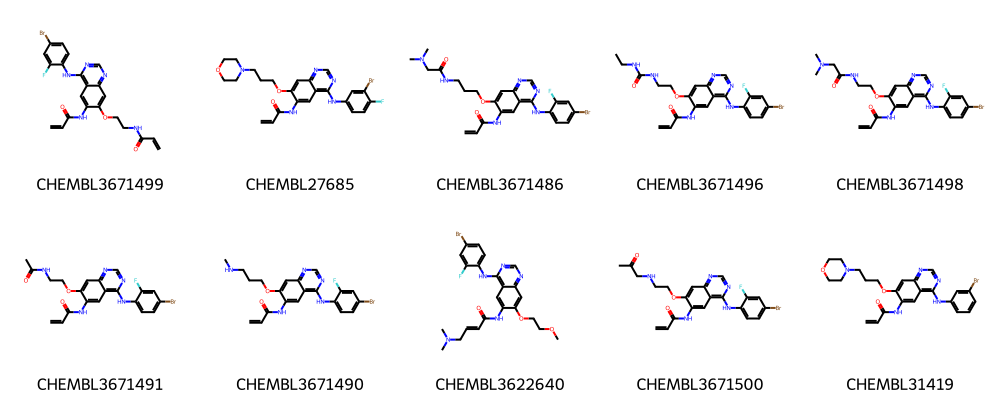

In [5]:
# 仅显示前 10 个分子，使用切片
num_mols = 10
legends = [mol.GetProp("_Name") for mol in mols]
Draw.MolsToGridImage(mols[:num_mols], legends=legends[:num_mols], molsPerRow=5)

### 使用不同输入参数运行 FMCS 算法

FMCS 算法在 RDKit 中实现：[rdFMCS](https://rdkit.org/docs/source/rdkit.Chem.rdFMCS.html)


#### 默认值

在最简单的情况下，只需将分子列表作为参数给出。


In [6]:
mcs1 = rdFMCS.FindMCS(mols)
print(f"MCS1 contains {mcs1.numAtoms} atoms and {mcs1.numBonds} bonds.")
print("MCS SMARTS string:", mcs1.smartsString)
# NBVAL_CHECK_OUTPUT

MCS1 contains 24 atoms and 26 bonds.
MCS SMARTS string: [#6]-[#6](=[#8])-[#7]-[#6]1:[#6]:[#6]2:[#6](-[#7]-[#6]3:[#6]:[#6]:[#6]:[#6]:[#6]:3):[#7]:[#6]:[#7]:[#6]:2:[#6]:[#6]:1-[#8]-[#6]-[#6]


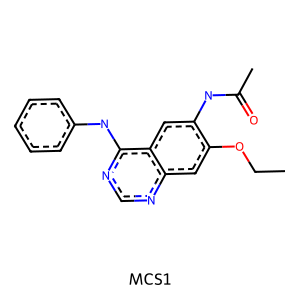

In [7]:
# 从 SMARTS 绘制子结构
m1 = Chem.MolFromSmarts(mcs1.smartsString)
Draw.MolToImage(m1, legend="MCS1")

定义一个辅助函数，用于绘制高亮显示 MCS 的分子。


In [8]:
def highlight_molecules(molecules, mcs, number, label=True, same_orientation=True, **kwargs):
    """在高亮显示查询分子中的 MCS。"""
    molecules = deepcopy(molecules)
    # 将 MCS 转换为分子
    pattern = Chem.MolFromSmarts(mcs.smartsString)
    # 查找每个分子中的匹配原子
    matching = [molecule.GetSubstructMatch(pattern) for molecule in molecules[:number]]

    legends = None
    if label is True:
        legends = [x.GetProp("_Name") for x in molecules]

    # 按匹配子结构对齐，使分子以相同方向显示
    # Adapted from: https://gist.github.com/greglandrum/82d9a86acb3b00d3bb1df502779a5810
    if same_orientation:
        mol, match = molecules[0], matching[0]
        AllChem.Compute2DCoords(mol)
        coords = [mol.GetConformer().GetAtomPosition(x) for x in match]
        coords2D = [Geometry.Point2D(pt.x, pt.y) for pt in coords]
        for mol, match in zip(molecules[1:number], matching[1:number]):
            if not match:
                continue
            coord_dict = {match[i]: coord for i, coord in enumerate(coords2D)}
            AllChem.Compute2DCoords(mol, coordMap=coord_dict)

    return Draw.MolsToGridImage(
        molecules[:number],
        legends=legends,
        molsPerRow=5,
        highlightAtomLists=matching[:number],
        subImgSize=(200, 200),
        **kwargs,
    )

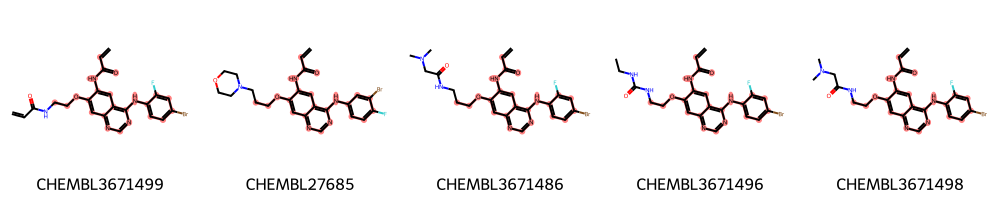

In [9]:
highlight_molecules(mols, mcs1, 5)

将图像保存到磁盘。


In [10]:
img = highlight_molecules(mols, mcs1, 3, useSVG=True)

# 获取 SVG 数据
molsvg = img.data

# 将背景设为透明并放大标签尺寸
molsvg = molsvg.replace("opacity:1.0", "opacity:0.0").replace("12px", "20px")

# 将修改后的 SVG 数据保存到文件
with open(DATA / "mcs_largest_cluster.svg", "w") as f:
    f.write(molsvg)

#### 设置阈值

可以降低子结构的阈值，例如让 MCS 只需出现在 80% 的输入结构中。


In [11]:
mcs2 = rdFMCS.FindMCS(mols, threshold=0.8)
print(f"MCS2 contains {mcs2.numAtoms} atoms and {mcs2.numBonds} bonds.")
print("SMARTS string:", mcs2.smartsString)
# NBVAL_CHECK_OUTPUT

MCS2 contains 28 atoms and 30 bonds.
SMARTS string: [#6]=[#6]-[#6](=[#8])-[#7]-[#6]1:[#6]:[#6]2:[#6](-[#7]-[#6]3:[#6]:[#6]:[#6]:[#6]:[#6]:3-[#9]):[#7]:[#6]:[#7]:[#6]:2:[#6]:[#6]:1-[#8]-[#6]-[#6]-[#7]-[#6]


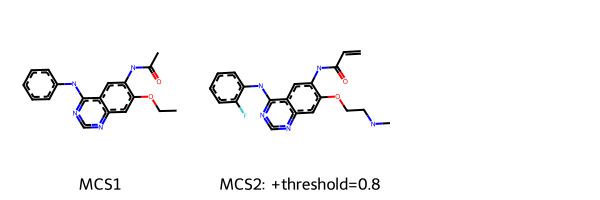

In [12]:
# 绘制子结构
m2 = Chem.MolFromSmarts(mcs2.smartsString)
Draw.MolsToGridImage([m1, m2], legends=["MCS1", "MCS2: +threshold=0.8"])

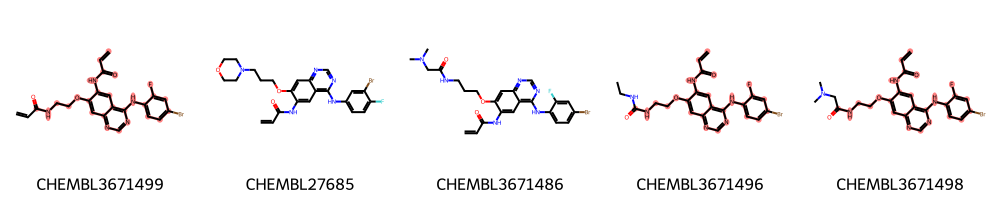

In [13]:
highlight_molecules(mols, mcs2, 5)

<!-- FIXME: CI - CHEMBL27685 id is not in this subset, check that T005 produces deterministic outputs -->
正如我们在本例中看到的，由于设置了阈值（`0.8`），部分分子被排除在外。该阈值允许找到一个更大的公共子结构，其中包含例如具有间位取代氟模式和较长烷烃链的苯环。


#### 匹配环键

在上面的例子中可能不明显，但默认情况下环键可以匹配非环键。
通常从应用角度来看，我们希望保留环结构。因此，可以将 `ringMatchesRingOnly` 参数设置为 `True`，这样只有环键与其他环键匹配。


In [14]:
mcs3 = rdFMCS.FindMCS(mols, threshold=0.8, ringMatchesRingOnly=True)
print(f"MCS3 contains {mcs3.numAtoms} atoms and {mcs3.numBonds} bonds.")
print("SMARTS string:", mcs3.smartsString)
# NBVAL_CHECK_OUTPUT

MCS3 contains 28 atoms and 30 bonds.
SMARTS string: [#6&!R]=&!@[#6&!R]-&!@[#6&!R](=&!@[#8&!R])-&!@[#7&!R]-&!@[#6]1:&@[#6]:&@[#6]2:&@[#6](-&!@[#7&!R]-&!@[#6]3:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@3-&!@[#9&!R]):&@[#7]:&@[#6]:&@[#7]:&@[#6]:&@2:&@[#6]:&@[#6]:&@1-&!@[#8&!R]-&!@[#6&!R]-&!@[#6&!R]-&!@[#7&!R]-&!@[#6&!R]


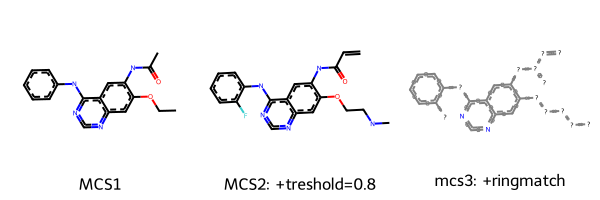

In [15]:
# 绘制子结构
m3 = Chem.MolFromSmarts(mcs3.smartsString)
Draw.MolsToGridImage([m1, m2, m3], legends=["MCS1", "MCS2: +treshold=0.8", "mcs3: +ringmatch"])

我们可以看到，根据所选的阈值和参数不同，得到的 MCS 略有差异。请注意，[RDKit FMCS 模块](https://www.rdkit.org/docs/GettingStartedInPython.html#maximum-common-substructure)还提供了更多参数选项，例如考虑原子、键或价态匹配。


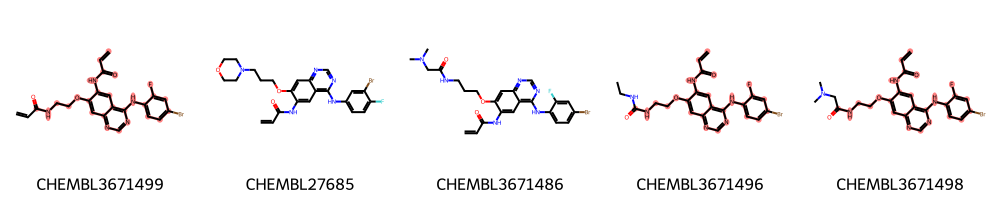

In [16]:
highlight_molecules(mols, mcs3, 5)

### 更多样化的集合：从 ChEMBL 下载的 EGFR 化合物

我们将数据限制为高活性分子（pIC50 > 9），并在该子集中检测最大公共骨架。


In [17]:
# 读取完整 EGFR 数据
mol_df = pd.read_csv(DATA / "EGFR_compounds.csv", index_col=0)
print("Total number of compounds:", mol_df.shape[0])

# 仅保留 pIC50 > 9 的分子（IC50 > 1 nM）
mol_df = mol_df[mol_df.pIC50 > 9]
print("Number of compounds with pIC50 > 9:", mol_df.shape[0])
# NBVAL_CHECK_OUTPUT

Total number of compounds: 5568
Number of compounds with pIC50 > 9: 186


,molecule_chembl_id,IC50,units,smiles,pIC50,ROMol
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,
2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,
3,CHEMBL66031,0.008,nM,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,11.096910,
4,CHEMBL53753,0.008,nM,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910,
...,...,...,...,...,...,...
181,CHEMBL165630,0.930,nM,OCCN(CCO)CCNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,9.031517,
182,CHEMBL189779,0.940,nM,CN(C)C/C=C/C(=O)Nc1ccc2ncnc(Nc3cccc(I)c3)c2c1,9.026872,
183,CHEMBL31816,0.950,nM,C=CC(=O)Nc1nc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC,9.022276,
184,CHEMBL328106,0.960,nM,COc1cc2ncnc(Nc3ccc(Br)cc3)c2cc1OC,9.017729,

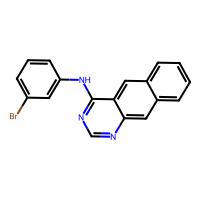
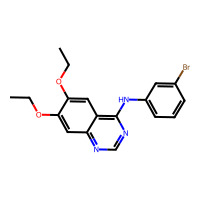
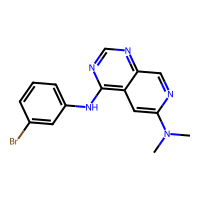
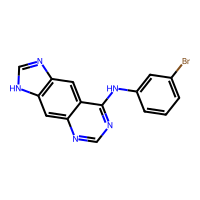
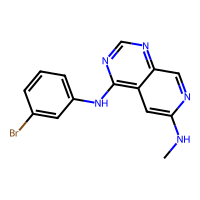
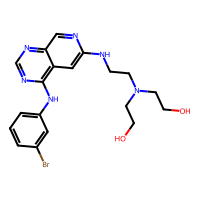
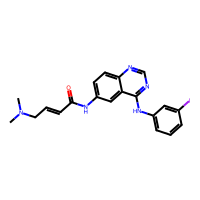
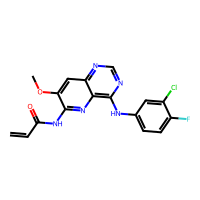
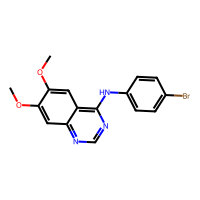
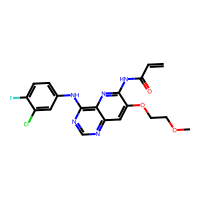

In [30]:
# 向数据框添加分子列
PandasTools.AddMoleculeColumnToFrame(mol_df, "smiles")
mol_df

我们只对选定的高活性分子进行计算。


In [19]:
mols_diverse = []
# 注：不关心的弃用变量通常用单个下划线表示
for _, row in mol_df.iterrows():
    m = Chem.MolFromSmiles(row.smiles)
    m.SetProp("_Name", row.molecule_chembl_id)
    mols_diverse.append(m)

为了节省时间，我们从该集合中随机选取 50 个分子。


In [20]:
# 上方导入部分已固定随机种子，以获得确定性结果
mols_diverse_sample = random.sample(mols_diverse, 50)

现在，我们计算与上述相同的三种 MCS 变体，并绘制相应子结构。由于该集合多样性更大，我们使用略低的阈值。


In [21]:
threshold_diverse = 0.7
mcs1 = rdFMCS.FindMCS(mols_diverse_sample)
print("SMARTS string1:", mcs1.smartsString)
mcs2 = rdFMCS.FindMCS(mols_diverse_sample, threshold=threshold_diverse)
print("SMARTS string2:", mcs2.smartsString)
mcs3 = rdFMCS.FindMCS(mols_diverse_sample, ringMatchesRingOnly=True, threshold=threshold_diverse)
print("SMARTS string3:", mcs3.smartsString)
# NBVAL_CHECK_OUTPUT

SMARTS string1: [#6](:,-[#6]:,-[#6]:,-[#6]:,-[#7]:,-[#6]):,-[#6]:,-[#6]
SMARTS string2: [#6]1:[#6]:[#6]:[#6]:[#6](:[#6]:1):,-[#7]:,-[#6]:[#7]:[#6]-,:[#7]-,:[#6]1:[#6]:[#6]:[#6]:[#6]:[#6]:1
SMARTS string3: [#6&R](:&@[#6&R]):&@[#6&R]:&@[#6&R](:&@[#7&R]:&@[#6&R]:&@[#7&R]:&@[#6&R]-&!@[#7&!R]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1):&@[#6&R]


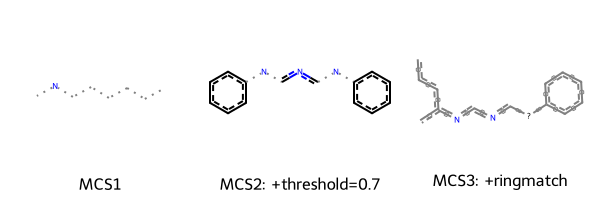

In [22]:
# 绘制子结构
m1 = Chem.MolFromSmarts(mcs1.smartsString)
m2 = Chem.MolFromSmarts(mcs2.smartsString)
m3 = Chem.MolFromSmarts(mcs3.smartsString)

Draw.MolsToGridImage(
    [m1, m2, m3],
    legends=[
        "MCS1",
        f"MCS2: +threshold={threshold_diverse}",
        "MCS3: +ringmatch",
    ],
)

这一次更清楚地表明，设置 `ringMatchesRingOnly=True` 能为它们共享的骨架提供更直观的表示。


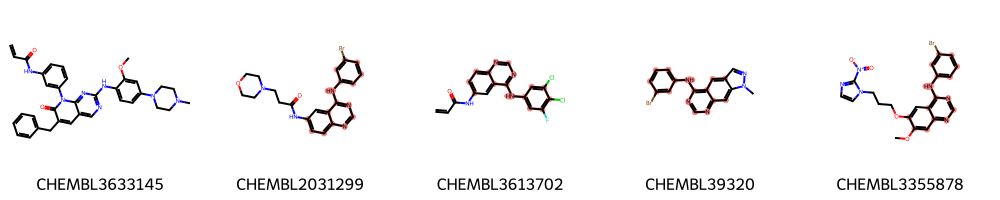

In [23]:
highlight_molecules(mols_diverse_sample, mcs3, 5)

### 使用交互式阈值调整识别 MCS

我们也可以交互式地更改阈值。为此，我们需要定义一个辅助函数。它接受两个参数：`molecules`（固定参数，因此不能通过小部件配置）和 `percentage`（其值由交互式小部件确定）。每次修改滑块状态时，都会调用此辅助函数。


In [24]:
def render_mcs(molecules, percentage):
    """交互式小部件辅助函数。`molecules` 必须用 `ipywidgets.fixed()` 包裹，
    而 `percentage` 由 IntSlider 小部件确定。"""
    tmcs = rdFMCS.FindMCS(molecules, threshold=percentage / 100.0)
    if tmcs is None:
        print("No MCS found")
        return None

    m = Chem.MolFromSmarts(tmcs.smartsString)
    print(tmcs.smartsString)
    return m

In [25]:
# 注意滑块可能需要几秒钟才会响应
interact(
    render_mcs,
    molecules=fixed(mols_diverse_sample),
    percentage=widgets.IntSlider(min=0, max=100, step=10, value=70),
);

interactive(children=(IntSlider(value=70, description='percentage', step=10), Output()), _dom_classes=('widget…

## 讨论

一组分子共有的最大子结构可以作为可视化共有骨架的有用策略。在本教程中，我们使用 FMCS 算法从 **教程 T005** 的最大簇中找到了最大公共子结构。交互式小部件使我们能够探索不同阈值对数据集中最大公共子结构的影响。


## 测验

* 为什么计算最大公共子结构（MCS）有用？
* 你能简要描述如何计算 MCS 吗？
* 活性 EGFR 化合物的典型片段是什么样的？
